# CTA200 2025 — Assignment 3
Questions 1 (Mandelbrot set), 2 (Lorenz system), and 3 (LaTeX writeup figures).

## Question 1 — Mandelbrot Set

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mandelbrot import mandelbrot_iterate


N = 800
x = np.linspace(-2, 2, N)
y = np.linspace(-2, 2, N)
X, Y = np.meshgrid(x, y)
C = X + 1j * Y

diverge_iter, diverged = mandelbrot_iterate(C, max_iter=100)

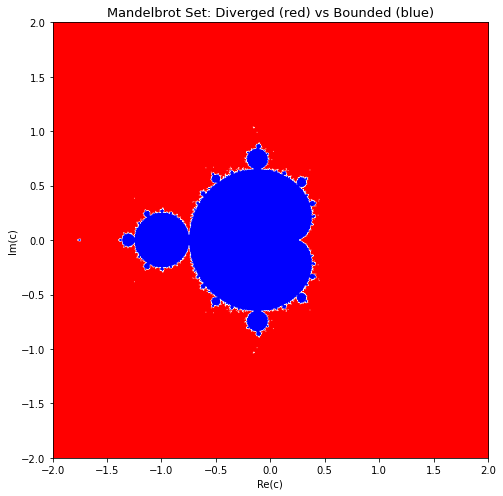

In [3]:

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(
    diverged,
    extent=[-2, 2, -2, 2],
    origin='lower',
    cmap='bwr',
    interpolation='bilinear'
)
ax.set_title('Mandelbrot Set: Diverged (red) vs Bounded (blue)', fontsize=13)
ax.set_xlabel('Re(c)')
ax.set_ylabel('Im(c)')
plt.tight_layout()
plt.savefig('mandelbrot_binary.pdf', dpi=150)
plt.show()

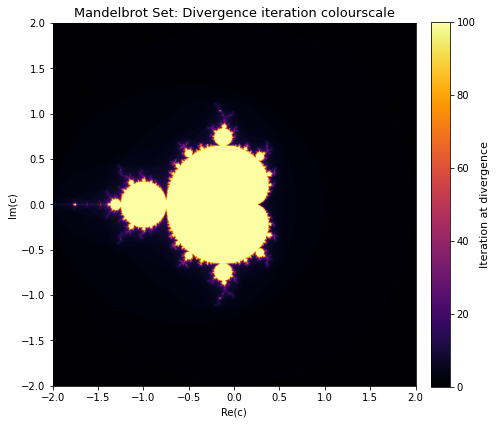

In [4]:

fig, ax = plt.subplots(figsize=(7, 7))
img = ax.imshow(
    diverge_iter,
    extent=[-2, 2, -2, 2],
    origin='lower',
    cmap='inferno',
    interpolation='bilinear'
)
cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Iteration at divergence', fontsize=11)
ax.set_title('Mandelbrot Set: Divergence iteration colourscale', fontsize=13)
ax.set_xlabel('Re(c)')
ax.set_ylabel('Im(c)')
plt.tight_layout()
plt.savefig('mandelbrot_coloured.pdf', dpi=150)
plt.show()

## Question 2 — Lorenz System

In [5]:
from scipy.integrate import solve_ivp
from lorenz import lorenz


sigma, r, b = 10., 28., 8./3.
params = (sigma, r, b)

W0 = [0., 1., 0.]
t_span = (0, 60)
dt = 0.01
t_eval = np.arange(0, 60 + dt, dt)

sol = solve_ivp(
    lorenz, t_span, W0,
    args=params,
    dense_output=True,
    rtol=1e-10, atol=1e-12
)

W = sol.sol(t_eval)  
X_sol, Y_sol, Z_sol = W


N_label = t_eval / dt

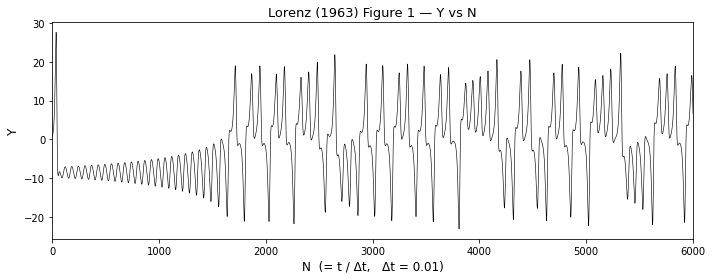

In [6]:

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(N_label, Y_sol, 'k-', linewidth=0.6)
ax.set_xlabel('N  (= t / Δt,   Δt = 0.01)', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('Lorenz (1963) Figure 1 — Y vs N', fontsize=13)
ax.set_xlim(0, N_label[-1])
plt.tight_layout()
plt.savefig('lorenz_fig1.pdf', dpi=150)
plt.show()

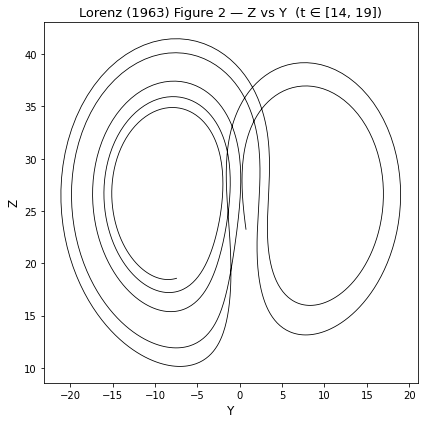

In [7]:

t_fine = np.linspace(14, 19, 1000)
W_fine = sol.sol(t_fine)
Y_fine, Z_fine = W_fine[1], W_fine[2]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(Y_fine, Z_fine, 'k-', linewidth=0.8)
ax.set_xlabel('Y', fontsize=12)
ax.set_ylabel('Z', fontsize=12)
ax.set_title('Lorenz (1963) Figure 2 — Z vs Y  (t ∈ [14, 19])', fontsize=13)
plt.tight_layout()
plt.savefig('lorenz_fig2.pdf', dpi=150)
plt.show()

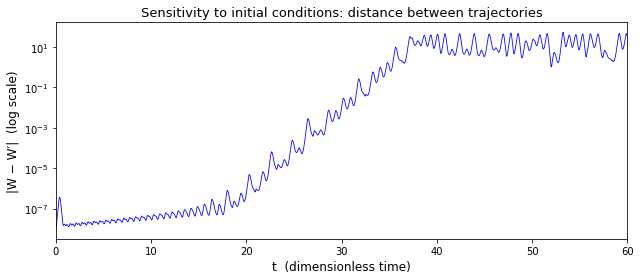

The straight-line segment on the semilog plot indicates exponential growth.
A tiny initial separation (~1e-8) grows to O(1) in ~30 dimensionless time units.


In [8]:

W0_prime = [0., 1. + 1e-8, 0.]  

sol_prime = solve_ivp(
    lorenz, t_span, W0_prime,
    args=params,
    dense_output=True,
    rtol=1e-10, atol=1e-12
)

W_prime = sol_prime.sol(t_eval)


dW = W - W_prime
distance = np.sqrt(np.sum(dW**2, axis=0))

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(t_eval, distance, 'b-', linewidth=0.8)
ax.set_xlabel('t  (dimensionless time)', fontsize=12)
ax.set_ylabel('|W − W′|  (log scale)', fontsize=12)
ax.set_title('Sensitivity to initial conditions: distance between trajectories', fontsize=13)
ax.set_xlim(0, 60)
plt.tight_layout()
plt.savefig('lorenz_sensitivity.pdf', dpi=150)
plt.show()

print('The straight-line segment on the semilog plot indicates exponential growth.')
print('A tiny initial separation (~1e-8) grows to O(1) in ~30 dimensionless time units.')